# 03 — Modelo Preditivo Opcional com Regressão Linear Múltipla

## Objetivo do notebook

Este notebook apresenta uma proposta simples de modelo preditivo para estimar a nota de satisfação do cliente (`nps_score`) antes da aplicação da pesquisa de NPS.

A estratégia escolhida foi utilizar **Regressão Linear Múltipla**, pois ela é uma extensão natural da Regressão Linear Simples:

- na Regressão Linear Simples, usamos **uma variável explicativa** para prever uma variável alvo;
- na Regressão Linear Múltipla, usamos **várias variáveis explicativas** para prever a variável alvo.

Neste projeto, o modelo tenta prever a nota de NPS em uma escala de 0 a 10. Depois disso, a nota prevista é convertida para a classificação tradicional do NPS:

```text
0 a 6   → Detrator
7 a 8   → Neutro
9 a 10  → Promotor
```

Essa abordagem mantém o modelo simples e, ao mesmo tempo, gera uma leitura mais próxima da lógica gerencial do NPS.

## Pergunta de negócio

A empresa consegue usar dados operacionais de pedidos, entrega e atendimento para antecipar se um cliente tende a ser detrator, neutro ou promotor?

## Observação importante

Este notebook tem finalidade didática e exploratória. A Regressão Linear Múltipla é simples, interpretável e adequada como primeiro modelo. Em fases futuras, modelos de classificação poderiam ser testados diretamente para prever as categorias de NPS.


## 1. Importação das bibliotecas

Nesta etapa, importamos as bibliotecas necessárias para:

- manipular os dados;
- separar treino e teste;
- treinar o modelo de regressão linear;
- avaliar os resultados;
- salvar o modelo treinado.


In [1]:
# CÉLULA 1 — IMPORTAÇÃO DAS BIBLIOTECAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, classification_report, accuracy_score

## 2. Definição dos caminhos do projeto

Como este notebook está dentro da pasta `notebooks/`, usamos `..` para voltar um nível e acessar as demais pastas do projeto.


In [2]:
# CÉLULA 2 — DEFINIÇÃO DOS CAMINHOS

BASE_DIR = Path("..")

RAW_DATA_PATH = BASE_DIR / "data" / "raw" / "desafio_nps_fase_1.csv"
MODELS_PATH = BASE_DIR / "models"
FIGURES_PATH = BASE_DIR / "reports" / "figures"

MODELS_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

## 3. Leitura da base de dados

A base contém informações de clientes, pedidos, logística, atendimento e satisfação.

A variável que será prevista pelo modelo é:

```text
nps_score
```

Essa variável representa a nota de satisfação do cliente em uma escala de 0 a 10.


In [3]:
# CÉLULA 3 — LEITURA DA BASE

df = pd.read_csv(RAW_DATA_PATH)

df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [4]:
# CÉLULA 4 — VISÃO GERAL DA BASE

print("Quantidade de linhas:", df.shape[0])
print("Quantidade de colunas:", df.shape[1])

df.info()

Quantidade de linhas: 2500
Quantidade de colunas: 19
<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  custom

## 4. Criação da classificação tradicional do NPS

Antes de treinar o modelo, vamos criar uma função para transformar a nota de NPS em categoria.

Essa função será usada em dois momentos:

1. para classificar a nota real do cliente;
2. para classificar a nota prevista pelo modelo.


In [5]:
# CÉLULA 5 — FUNÇÃO PARA CLASSIFICAR NPS

def classificar_nps(nota):
    if nota <= 6:
        return "Detrator"
    elif nota <= 8:
        return "Neutro"
    else:
        return "Promotor"

In [6]:
# CÉLULA 6 — CRIAÇÃO DA CLASSE REAL DO NPS

df["nps_class_real"] = df["nps_score"].apply(classificar_nps)

df[["nps_score", "nps_class_real"]].head()

,nps_score,nps_class_real
0,6.9,Neutro
1,2.4,Detrator
2,4.8,Detrator
3,5.9,Detrator
4,6.1,Neutro


In [7]:
# CÉLULA 7 — DISTRIBUIÇÃO DAS CLASSES REAIS

distribuicao_nps = (
    df["nps_class_real"]
    .value_counts()
    .rename_axis("classe_nps")
    .reset_index(name="quantidade")
)

distribuicao_nps["percentual"] = (
    distribuicao_nps["quantidade"] / distribuicao_nps["quantidade"].sum() * 100
).round(2)

distribuicao_nps

,classe_nps,quantidade,percentual
0,Detrator,1851,74.04
1,Neutro,448,17.92
2,Promotor,201,8.04


## 5. Seleção das variáveis de entrada

Nesta etapa, escolhemos as variáveis que serão usadas para prever o `nps_score`.

Foram removidos:

- `customer_id`, porque é apenas um identificador do cliente;
- `order_id`, porque é apenas um identificador do pedido;
- `nps_score`, porque é a variável alvo;
- `nps_class_real`, porque foi criada a partir da variável alvo.

A variável `customer_region` é categórica. Para que ela possa ser usada no modelo, será transformada em variáveis indicadoras com `pd.get_dummies()`.

Esse processo cria colunas numéricas indicando a região do cliente.


In [8]:
# CÉLULA 8 — PREPARAÇÃO DA BASE PARA MODELAGEM

df_model = df.copy()

# Remove identificadores que não devem ser usados como variáveis explicativas
df_model = df_model.drop(columns=["customer_id", "order_id"])

# Transforma a variável categórica customer_region em variáveis numéricas
df_model = pd.get_dummies(
    df_model,
    columns=["customer_region"],
    drop_first=True
)

df_model.head()

,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,...,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_class_real,customer_region_Nordeste,customer_region_Norte,customer_region_Sudeste,customer_region_Sul
0,63,14,139.73,4,39.35,4,2,2,55.53,3,...,4,6.9,0,3,6.5,Neutro,True,False,False,False
1,20,1,458.95,2,9.51,10,6,4,28.23,3,...,10,2.4,0,3,0.0,Detrator,False,False,False,True
2,46,111,507.06,5,42.82,6,6,1,40.99,1,...,5,4.8,0,7,1.5,Detrator,True,False,False,False
3,52,117,302.19,2,19.58,9,5,2,35.24,3,...,11,5.9,0,4,0.3,Detrator,False,False,False,False
4,56,50,253.06,1,29.37,11,13,1,39.32,1,...,0,6.1,0,3,7.9,Neutro,False,True,False,False


## 6. Separação entre variável alvo e variáveis explicativas

A variável alvo é:

```text
y = nps_score
```

As variáveis explicativas são todas as demais colunas operacionais disponíveis, exceto a classificação real do NPS.


In [9]:
# CÉLULA 9 — DEFINIÇÃO DE X E y

X = df_model.drop(columns=["nps_score", "nps_class_real"])
y = df_model["nps_score"]

print("Quantidade de variáveis explicativas:", X.shape[1])
print("Variável alvo:", y.name)

Quantidade de variáveis explicativas: 19
Variável alvo: nps_score


In [10]:
# CÉLULA 10 — LISTA DE VARIÁVEIS EXPLICATIVAS

pd.DataFrame({"variavel": X.columns})

,variavel
0,customer_age
1,customer_tenure_months
2,order_value
3,items_quantity
4,discount_value
5,payment_installments
6,delivery_time_days
7,delivery_delay_days
8,freight_value
9,delivery_attempts


## 7. Separação entre treino e teste

A base será separada em duas partes:

- **treino:** usada para o modelo aprender os padrões;
- **teste:** usada para avaliar o desempenho em dados que o modelo ainda não viu.

Usaremos 80% dos dados para treino e 20% para teste.


In [11]:
# CÉLULA 11 — SPLIT TREINO / TESTE

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2000, 19)
X_test: (500, 19)
y_train: (2000,)
y_test: (500,)


## 8. Treinamento do modelo

Agora treinamos o modelo de **Regressão Linear Múltipla**.

A lógica geral do modelo é:

```text
nps_score = intercepto + b1*x1 + b2*x2 + b3*x3 + ... + erro
```

Ou seja, o modelo combina várias informações do cliente, pedido, entrega e atendimento para estimar uma nota de NPS.


In [12]:
# CÉLULA 12 — TREINAMENTO DO MODELO

modelo = LinearRegression()

modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 9. Geração das previsões

O modelo gera uma nota prevista de NPS.

Como o NPS real varia de 0 a 10, vamos limitar as previsões a essa escala usando `np.clip()`.

Depois, arredondamos a nota prevista para facilitar a leitura gerencial.


In [13]:
# CÉLULA 13 — PREVISÕES DO MODELO

y_pred = modelo.predict(X_test)

# Garante que as previsões fiquem dentro da escala do NPS: 0 a 10
y_pred_ajustado = np.clip(y_pred, 0, 10)

# Arredonda a nota prevista
y_pred_arredondado = np.round(y_pred_ajustado)

resultados = pd.DataFrame({
    "nps_real": y_test.values,
    "nps_previsto": y_pred_ajustado,
    "nps_previsto_arredondado": y_pred_arredondado
})

resultados.head()

,nps_real,nps_previsto,nps_previsto_arredondado
0,6.8,5.044192,5.0
1,6.0,5.767388,6.0
2,8.3,10.000000,10.0
3,5.3,4.250972,4.0
4,6.8,6.240678,6.0


## 10. Avaliação do modelo como regressão

Como o modelo prevê uma nota numérica, primeiro avaliamos o desempenho como problema de regressão.

As métricas utilizadas são:

- **MAE:** erro absoluto médio;
- **RMSE:** raiz do erro quadrático médio;
- **R²:** indica quanto da variação da variável alvo é explicada pelo modelo.

Para uma leitura simples:

- quanto menor o MAE e o RMSE, melhor;
- quanto maior o R², melhor.


In [14]:
# CÉLULA 14 — MÉTRICAS DE REGRESSÃO

mae = mean_absolute_error(y_test, y_pred_ajustado)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_ajustado))
r2 = r2_score(y_test, y_pred_ajustado)

metricas_regressao = pd.DataFrame({
    "metrica": ["MAE", "RMSE", "R²"],
    "valor": [mae, rmse, r2]
})

metricas_regressao

,metrica,valor
0,MAE,1.186981
1,RMSE,1.493392
2,R²,0.647045


## 11. Classificação das notas previstas

Agora vamos converter a nota prevista pelo modelo em categoria NPS.

Exemplos:

- se o modelo previu nota 4, o cliente será classificado como **Detrator**;
- se o modelo previu nota 7, o cliente será classificado como **Neutro**;
- se o modelo previu nota 10, o cliente será classificado como **Promotor**.


In [15]:
# CÉLULA 15 — CLASSIFICAÇÃO DA NOTA REAL E DA NOTA PREVISTA

resultados["classe_real"] = resultados["nps_real"].apply(classificar_nps)
resultados["classe_prevista"] = resultados["nps_previsto_arredondado"].apply(classificar_nps)

resultados.head(10)

,nps_real,nps_previsto,nps_previsto_arredondado,classe_real,classe_prevista
0,6.8,5.044192,5.0,Neutro,Detrator
1,6.0,5.767388,6.0,Detrator,Detrator
2,8.3,10.000000,10.0,Promotor,Promotor
3,5.3,4.250972,4.0,Detrator,Detrator
4,6.8,6.240678,6.0,Neutro,Detrator
5,0.0,1.637805,2.0,Detrator,Detrator
6,1.4,0.000000,0.0,Detrator,Detrator
7,7.4,5.469945,5.0,Neutro,Detrator
8,5.2,4.421444,4.0,Detrator,Detrator
9,0.8,3.353448,3.0,Detrator,Detrator


## 12. Avaliação da classificação derivada

Embora o modelo tenha sido treinado como regressão, podemos avaliar como ficaram as classes finais de NPS.

Essa análise mostra se a nota prevista pelo modelo está conseguindo separar corretamente clientes em:

```text
Detrator, Neutro, Promotor
```


In [16]:
# CÉLULA 16 — ACURÁCIA DA CLASSIFICAÇÃO DERIVADA

acuracia = accuracy_score(
    resultados["classe_real"],
    resultados["classe_prevista"]
)

print(f"Acurácia da classificação derivada: {acuracia:.2%}")

Acurácia da classificação derivada: 79.00%


In [17]:
# CÉLULA 17 — MATRIZ DE CONFUSÃO

classes = ["Detrator", "Neutro", "Promotor"]

matriz_confusao = confusion_matrix(
    resultados["classe_real"],
    resultados["classe_prevista"],
    labels=classes
)

matriz_confusao_df = pd.DataFrame(
    matriz_confusao,
    index=[f"Real: {classe}" for classe in classes],
    columns=[f"Previsto: {classe}" for classe in classes]
)

matriz_confusao_df

,Previsto: Detrator,Previsto: Neutro,Previsto: Promotor
Real: Detrator,361,2,0
Real: Neutro,87,9,2
Real: Promotor,0,14,25


In [18]:
# CÉLULA 18 — RELATÓRIO DE CLASSIFICAÇÃO

print(
    classification_report(
        resultados["classe_real"],
        resultados["classe_prevista"],
        labels=classes
    )
)

              precision    recall  f1-score   support

    Detrator       0.81      0.99      0.89       363
      Neutro       0.36      0.09      0.15        98
    Promotor       0.93      0.64      0.76        39

    accuracy                           0.79       500
   macro avg       0.70      0.58      0.60       500
weighted avg       0.73      0.79      0.73       500



## 13. Comparação visual entre classes reais e previstas

O gráfico abaixo compara a distribuição das classes reais com a distribuição das classes previstas pelo modelo.

Esse gráfico é útil para verificar se o modelo está superestimando ou subestimando alguma categoria.


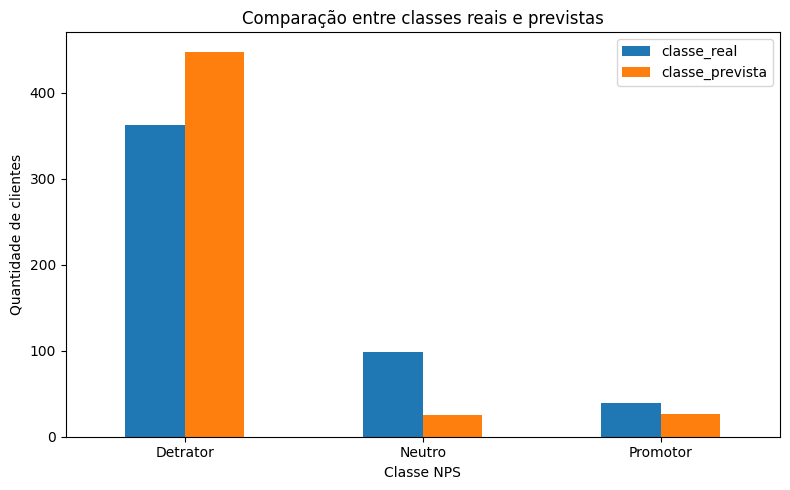

In [19]:
# CÉLULA 19 — GRÁFICO DE BARRAS: CLASSES REAIS VS PREVISTAS

comparacao_classes = pd.DataFrame({
    "classe_real": resultados["classe_real"].value_counts(),
    "classe_prevista": resultados["classe_prevista"].value_counts()
}).fillna(0)

comparacao_classes = comparacao_classes.reindex(classes)

comparacao_classes.plot(kind="bar", figsize=(8, 5))

plt.title("Comparação entre classes reais e previstas")
plt.xlabel("Classe NPS")
plt.ylabel("Quantidade de clientes")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(FIGURES_PATH / "modelo_classes_reais_vs_previstas.png", dpi=300, bbox_inches="tight")
plt.show()

## 14. Interpretação dos coeficientes do modelo

A Regressão Linear permite observar o peso estimado de cada variável.

De forma simplificada:

- coeficiente positivo: aumento da variável tende a aumentar a nota prevista de NPS;
- coeficiente negativo: aumento da variável tende a reduzir a nota prevista de NPS.

Essa interpretação deve ser feita com cuidado, pois correlação e modelo linear não provam causalidade.


In [20]:
# CÉLULA 20 — COEFICIENTES DO MODELO

coeficientes = pd.DataFrame({
    "variavel": X.columns,
    "coeficiente": modelo.coef_
})

coeficientes["coeficiente_absoluto"] = coeficientes["coeficiente"].abs()

coeficientes = coeficientes.sort_values(
    by="coeficiente_absoluto",
    ascending=False
)

coeficientes.head(15)

,variavel,coeficiente,coeficiente_absoluto
12,repeat_purchase_30d,2.851252,2.851252
7,delivery_delay_days,-0.852549,0.852549
10,customer_service_contacts,-0.384696,0.384696
13,complaints_count,-0.271488,0.271488
18,customer_region_Sul,0.198531,0.198531
15,customer_region_Nordeste,0.185200,0.185200
16,customer_region_Norte,0.178858,0.178858
11,resolution_time_days,-0.150414,0.150414
17,customer_region_Sudeste,0.126737,0.126737
9,delivery_attempts,0.083368,0.083368


## 15. Salvamento do modelo

O modelo será salvo na pasta `models/`.

Esse arquivo poderia ser reutilizado posteriormente para gerar previsões em novos pedidos.


In [21]:
# CÉLULA 21 — SALVAMENTO DO MODELO

MODEL_PATH = MODELS_PATH / "modelo_regressao_linear_multipla_nps.pkl"

with open(MODEL_PATH, "wb") as file:
    pickle.dump(modelo, file)

print(f"Modelo salvo em: {MODEL_PATH}")

Modelo salvo em: ..\models\modelo_regressao_linear_multipla_nps.pkl


## 16. Como essa solução poderia ser usada na prática

A empresa poderia usar esse modelo de forma preventiva dentro da jornada do cliente.

Exemplo de uso:

1. Um pedido é realizado.
2. A empresa acompanha dados operacionais como prazo de entrega, atraso, tentativas de entrega, contatos com atendimento e reclamações.
3. O modelo estima uma nota provável de NPS.
4. Essa nota é convertida em uma categoria: detrator, neutro ou promotor.
5. Clientes com maior risco de serem detratores podem ser priorizados em ações corretivas.

Possíveis ações de negócio:

- priorizar clientes com atraso elevado;
- acionar atendimento proativo antes da reclamação formal;
- oferecer compensações em casos críticos;
- monitorar regiões ou operações com maior risco de baixa satisfação;
- melhorar SLAs logísticos e processos de resolução.

## Limitações da abordagem

Apesar de ser simples e interpretável, esta abordagem possui limitações:

- a Regressão Linear prevê uma nota contínua, não uma classe diretamente;
- a classificação em detrator, neutro e promotor acontece depois da previsão;
- erros pequenos perto dos limites podem mudar a classe final, por exemplo nota prevista 8 ou 9;
- o modelo assume relações lineares entre variáveis e NPS;
- os resultados não devem ser interpretados como causalidade;
- novas variáveis de contexto poderiam melhorar a previsão.

## Conclusão

A Regressão Linear Múltipla é uma boa primeira abordagem para este desafio porque é simples, interpretável e conecta diretamente as variáveis operacionais à nota de NPS.

Mesmo sendo um modelo básico, ele permite transformar dados de pedidos, entrega e atendimento em uma estimativa inicial de satisfação do cliente. A partir dessa nota prevista, é possível classificar clientes como detratores, neutros ou promotores, apoiando decisões gerenciais e ações preventivas de melhoria da experiência.
